---

### 🧾 **Probabilidad Básica en Python**


---

## 🧪 Actividad en Python para Google Colab

> 📍 **Objetivo**: Aplicar conceptos de probabilidad clásica y frecuentista mediante simulaciones, combinaciones y visualización en Python.


### 📄 Declaración de traducción

> Este código fue traducido y adaptado del lenguaje **R** al lenguaje **Python** con la asistencia de **Microsoft Copilot**, con el objetivo de facilitar su implementación en el entorno **Google Colab**.  
> La estructura pedagógica, los ejemplos reproducibles y los conceptos fundamentales fueron preservados para promover la comprensión progresiva de la probabilidad básica.

---

# Fuente: https://bookdown.org/dparedesi/data-science-con-r/probabilidades-discretas.html
# Autor: Pastor E. Pérez Estigarribia
# e-mail: peperez.estigarribia@gmail.com

---

### 🔹 Secciones clave:



2. **Simulación de Montecarlo**: Se repite el experimento de selección aleatoria múltiples veces para estimar la probabilidad de forma frecuentista. Se usa `sample()` y `replicate()` para generar resultados, y `table()` para resumirlos.

3. **Valor esperado**: Se calcula la proporción de hombres usando `mean()` sobre una condición lógica.

4. **Permutaciones y combinaciones**: Se explora la probabilidad de que ciertos estudiantes ocupen posiciones específicas en una competencia, utilizando `gtools::permutations()` y `gtools::combinations()`.

5. **Simulación progresiva**: Se estima cómo varía la probabilidad de un evento al aumentar el número de repeticiones, visualizando los resultados con `ggplot2`.

6. **Problema del cumpleaños**: Se estima la probabilidad de que al menos dos personas compartan cumpleaños en una clase de tamaño variable, usando simulación y funciones personalizadas.

#### 🔰 0. Preparación del entorno

In [ ]:
# Instala paquetes necesarios
!pip install numpy pandas matplotlib seaborn

#### ➕ 1. Probabilidad clásica

1. **Definición clásica de probabilidad**: Se calcula la probabilidad de seleccionar un hombre en un grupo de 10 personas (6 hombres, 4 mujeres) usando la fórmula clásica $ P(A) = \frac{\text{casos favorables}}{\text{casos posibles}} $.

In [ ]:
# Grupo: 4 mujeres, 6 hombres
# si tenemos en un salón sentados a 4 mujeres y 6 hombres e hiciésemos
# un sorteo de 1 premio intuitivamente sabríamos que la probabilidad de que
# el sorteado sea hombre es de 60%.
# La probabilidad que obtuvimos por intuición en el ejemplo anterior
# se puede expresar de la siguiente forma:
# P(A) = Veces que el evento A se puede/Total de resultados posibles
# P(hombres) = 6/10
P_h = 6 / 10
print("Probabilidad de seleccionar un hombre:", P_h)

Probabilidad de seleccionar un hombre: 0.6


### 1. Probabilidad clásica

**Definición (clásica).** Si todos los resultados son igualmente probables,
$$
P(A) = \frac{\text{casos favorables}}{\text{casos posibles}}.
$$

**Ejemplo.** En un salón con 6 hombres y 4 mujeres, la probabilidad de seleccionar un hombre es
$$
P(\text{hombre})=\frac{6}{10}=0.6.
$$

**Definición:**
$$
P(A)=\frac{|A|}{|\Omega|},\quad \Omega=\{ \text{todos los resultados posibles} \}.
$$


#### 🎲 2. [Simulación de Montecarlo](https://en.wikipedia.org/wiki/Monte_Carlo_method)

 _Definición frecuentista de probabilidad_


 La simulación o método de Montecarlo es un método estadístico utilizado para resolver problemas matemáticos complejos a través de la generación de variables aleatorias.

Usaremos simulación Montecarlo para estimar la proporción qué obtendríamos si repitiésemos este experimento de forma aleatoria un número determinado de veces. Es decir, la probabilidad del evento usando esta estimación sería la proporción de veces en que ocurrió ese evento en nuestra simulación.

> A finales de la década de 1940, [Stanisław Ulam inventó la versión moderna del método de Monte Carlo](https://www.youtube.com/watch?v=m4X94Sq1Q4M) de la Cadena de Markov [mientras trabajaba en proyectos de armas nucleares en el Laboratorio Nacional de Los Álamos](https://youtu.be/6pO6Mm2qJaE?si=7Vav5wN38pEKHhHh).

> Método de Monte Carlo aplicado para aproximar el valor de π
![](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Pi_monte_carlo_all.gif/330px-Pi_monte_carlo_all.gif)

### 2. Probabilidad frecuentista y simulación Monte Carlo

**Definición (frecuentista).** La probabilidad de un evento se estima como la proporción de veces que ocurre al repetir el experimento muchas veces:
$$
\hat P(A)=\frac{1}{N}\sum_{i=1}^{N} \mathbf{1}_{\{A\}}(X_i),
$$
donde $\mathbf{1}_{\{A\}}$ es la función indicadora.

**Convergencia (ley de los grandes números, enunciado informal):**
$$
\hat P(A)\xrightarrow{a.s.} P(A)\quad\text{cuando }N\to\infty.
$$

**Nota:** El cuaderno usa simulación Monte Carlo para estimar proporciones repitiendo el experimento aleatorio muchas veces.


In [ ]:
import numpy as np

# Crear vector de estudiantes
estudiantes = ["mujer"] * 4 + ["hombre"] * 6
estudiantes

['mujer',
 'mujer',
 'mujer',
 'mujer',
 'hombre',
 'hombre',
 'hombre',
 'hombre',
 'hombre',
 'hombre']

In [ ]:
# Simulación de 100 repeticiones
num_veces = 10000
resultados = np.random.choice(estudiantes, num_veces)
resultados

array(['hombre', 'hombre', 'hombre', ..., 'hombre', 'mujer', 'mujer'],
      dtype='<U6')

✏️ **Actividad**: Explorar la función explicar codigo de colab.

In [ ]:
# Tabla de frecuencias
from collections import Counter
tabla = Counter(resultados)
print("Frecuencias:", tabla)

Frecuencias: Counter({np.str_('hombre'): 5955, np.str_('mujer'): 4045})


In [ ]:
# Proporciones
proporciones = {k: v / num_veces for k, v in tabla.items()}
print("Proporciones:", proporciones)

Proporciones: {np.str_('hombre'): 0.5955, np.str_('mujer'): 0.4045}


✏️ **Actividad**: aumentar el num_veces a 10000 y luego a 100000 y comparar los resultados.

#### 📈 3. Simulación extendida y valor esperado

 Valor esperado: Finalmente, para este ejemplo sencillo también podríamos  haber utilizado la función mean(). Si bien esto nos calcula el promedio de un conjunto de números, podríamos convertir nuestro vector estudiantes a valores númericos, donde cada valor lo convirtamos en 1 o 0 dependiendo de alguna condicion.

### 3. Valor esperado y proporción como esperanza

Si codificamos el evento "éxito" como variable aleatoria $Y$ con $Y=1$ si ocurre el evento y $Y=0$ en caso contrario, entonces
$$
E[Y]=P(\text{éxito}).
$$

**Estimador por simulación:**
$$
\hat E[Y]=\frac{1}{N}\sum_{i=1}^N Y_i.
$$



In [ ]:
# Simulación de 10,000 repeticiones
num_veces = 10000
resultados = np.random.choice(estudiantes, num_veces)
esperado = np.mean(resultados == "hombre")
print("Valor esperado (proporción de hombres):", esperado)

Valor esperado (proporción de hombres): 0.6032


✏️ **Actividad**: aumentar el num_veces y compara los resultados.

#### 🧮 4. Permutaciones y combinaciones

Importa el orden cuando calculamos, por ejemplo, los ganadores de una competencia. Supongamos que tenemos 10 estudiantes que están compitiendo en igualdad de condiciones por quién construye el modelo en machine learning más preciso.

 Solo los top 3 recibirán el premio. En este caso el orden importa, entonces usaremos la función permutations.


---

#### Celda 5 — Permutaciones y combinaciones (formulación)
```markdown
### 4. Permutaciones y combinaciones

**Permutaciones (orden importa).** Número de arreglos de $k$ elementos tomados de $n$:
$$
P(n,k)=\frac{n!}{(n-k)!}.
$$

**Combinaciones (orden no importa).** Número de subconjuntos de tamaño $k$:
$$
C(n,k)=\binom{n}{k}=\frac{n!}{k!(n-k)!}.
$$

**Ejemplo:** Para 10 participantes y premios para los 3 primeros:
$$
P(10,3)=\frac{10!}{7!}=720.
$$

**Probabilidad de un orden específico (ej.: Freddy primero, Pamela segundo):**
$$
P(\text{Freddy, Pamela})=\frac{\#\{\text{permutaciones con esa orden}\}}{P(10,3)}=\frac{1}{90}\approx 0.0111.
$$


In [ ]:
# Permutaciones

import itertools

data_scientists = [
    "Jenny", "Freddy", "Yasan", "Iver", "Pamela",
    "Alexandra", "Bladimir", "Enrique", "Karen", "Christiam"
]

# Permutaciones de 3
perms = list(itertools.permutations(data_scientists, 3))
total = len(perms)
print("Total de permutaciones:", total)

Total de permutaciones: 720


Ya hemos calculado todos los resultados posibles. Podemos sobre este resultado calcular la probabilidad de que Fredy gane la competencia y que Pamela quede en segundo lugar.

In [ ]:
# Probabilidad de Freddy primero y Pamela segundo
cond = [p for p in perms if p[0] == "Freddy" and p[1] == "Pamela"]
print("Probabilidad:", len(cond) / total)

Probabilidad: 0.011111111111111112


#### 🔁 5. Simulación progresiva - Combinaciones

No importa el orden cuando, por ejemplo, formamos grupos de a 2 para que participen en la competencia.

In [ ]:
combs = list(itertools.combinations(data_scientists, 2))
combs

[('Jenny', 'Freddy'),
 ('Jenny', 'Yasan'),
 ('Jenny', 'Iver'),
 ('Jenny', 'Pamela'),
 ('Jenny', 'Alexandra'),
 ('Jenny', 'Bladimir'),
 ('Jenny', 'Enrique'),
 ('Jenny', 'Karen'),
 ('Jenny', 'Christiam'),
 ('Freddy', 'Yasan'),
 ('Freddy', 'Iver'),
 ('Freddy', 'Pamela'),
 ('Freddy', 'Alexandra'),
 ('Freddy', 'Bladimir'),
 ('Freddy', 'Enrique'),
 ('Freddy', 'Karen'),
 ('Freddy', 'Christiam'),
 ('Yasan', 'Iver'),
 ('Yasan', 'Pamela'),
 ('Yasan', 'Alexandra'),
 ('Yasan', 'Bladimir'),
 ('Yasan', 'Enrique'),
 ('Yasan', 'Karen'),
 ('Yasan', 'Christiam'),
 ('Iver', 'Pamela'),
 ('Iver', 'Alexandra'),
 ('Iver', 'Bladimir'),
 ('Iver', 'Enrique'),
 ('Iver', 'Karen'),
 ('Iver', 'Christiam'),
 ('Pamela', 'Alexandra'),
 ('Pamela', 'Bladimir'),
 ('Pamela', 'Enrique'),
 ('Pamela', 'Karen'),
 ('Pamela', 'Christiam'),
 ('Alexandra', 'Bladimir'),
 ('Alexandra', 'Enrique'),
 ('Alexandra', 'Karen'),
 ('Alexandra', 'Christiam'),
 ('Bladimir', 'Enrique'),
 ('Bladimir', 'Karen'),
 ('Bladimir', 'Christiam'),
 ('E

Si ahora es un solo equipo el que va a ganar el premio, podríamos calcular la probabilidad de que el equipo conformado por Pamela y Enrique sean quienes ganen

In [ ]:
import itertools
import numpy as np

# Lista de participantes
data_scientists = [
    "Jenny", "Freddy", "Yasan", "Iver", "Pamela",
    "Alexandra", "Bladimir", "Enrique", "Karen", "Christiam"
]

# Generar todas las combinaciones posibles de 2 personas
combinaciones = list(itertools.combinations(data_scientists, 2))

# Total de combinaciones
total = len(combinaciones)
print("Total de combinaciones:", total)  # Resultado esperado: 45

Total de combinaciones: 45


In [ ]:
# Calcular la probabilidad de que Pamela y Enrique estén juntos (sin importar el orden)
conteo = sum(
    (a == "Pamela" and b == "Enrique") or (a == "Enrique" and b == "Pamela")
    for a, b in combinaciones
)

probabilidad = conteo / total
print("Probabilidad de que Pamela y Enrique estén juntos:", probabilidad)  # Resultado esperado: 0.022222..

Probabilidad de que Pamela y Enrique estén juntos: 0.022222222222222223


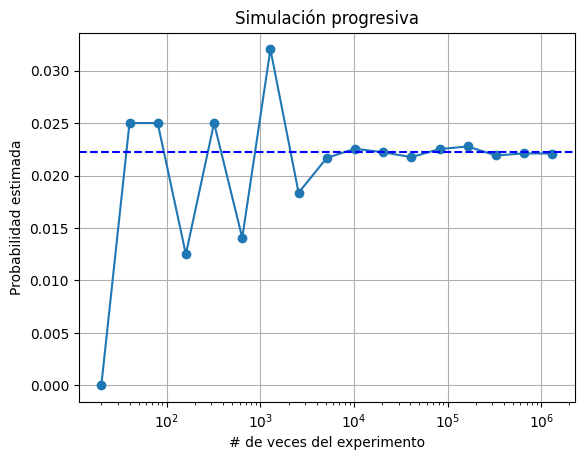

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def probabilidad_por_muestra(n):
    resultado = [
        np.random.choice(data_scientists, 2, replace=False)
        for _ in range(n)
    ]
    cumple = [
        (r[0] == "Pamela" and r[1] == "Enrique") or
        (r[1] == "Pamela" and r[0] == "Enrique")
        for r in resultado
    ]
    return np.mean(cumple)

num_veces = [10 * 2 ** i for i in range(1, 18)]
prob = [probabilidad_por_muestra(n) for n in num_veces]

df = pd.DataFrame({"n": num_veces, "probabilidad": prob})
plt.plot(df["n"], df["probabilidad"], marker='o')
plt.xscale("log")
plt.axhline(y=2/90, color='blue', linestyle='--')
plt.xlabel("# de veces del experimento")
plt.ylabel("Probabilidad estimada")
plt.title("Simulación progresiva")
plt.grid(True)
plt.show()

Nótese que, como vimos anteriormente, el valor converge conforme aumentamos la cantidad de veces que repetimos el experimento n. Hemos simulado repetir el experimento 10 mil veces. Sin embargo, ¿cuántas veces se necesitaría replicar el experimento para confiar en los resultados de la simulación.

Intuitivamente podemos indicar que a mayor cantidad de experimentos es más precisa la probabilidad estimada. Podemos, así, hacer varias simulaciones con diferente número de experimentos para cada simulación.



#### 🎂 6. Problema del cumpleaños

Utilizando simulación de Montecarlo estimemos cuál es la probabilidad de qué hayan al menos dos personas que cumplan años el mismo día. (Obviemos a los que cumplen años el 29 de febrero).

Primero listemos todos los días del año disponible para cumpleaños:

In [ ]:
dias = list(range(1, 366))

Generemos una muestra aleatoria de 50 números del vector dias, pero ésta vez con reemplazo porque una persona podría tener el mismo día, y almacenémoslo en la variable colegas.

In [ ]:
import numpy as np

dias = np.arange(1, 366)  # Vector de días del año
colegas = np.random.choice(dias, size=50, replace=True)
colegas

array([262, 363,  93, 234,  56,  77, 350, 232,  51, 325, 364, 211, 107,
       324, 248,  41, 212,   7,  59, 147, 134,  92, 334, 240,  69, 359,
       125, 147, 287,  31,  60, 214, 247, 153, 324,  12, 347, 284, 267,
       297, 332, 332,  73, 138, 212,  44, 264, 243, 246, 244])

Para validar si alguno de los valores se repite usaremos la función duplicated() que nos valida si dentro del vector hay valores duplicados:

In [ ]:
import numpy as np

# Ejemplo: vector de días con posibles duplicados
colegas = np.random.choice(np.arange(1, 366), size=50, replace=True)

# Detectar duplicados (equivalente a duplicated() en R)
duplicados = [colegas.tolist().index(x) != i for i, x in enumerate(colegas)]

print(duplicados)

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]


Finalmente, para determinar si hubo algún valor TRUE utilizamos:

In [ ]:
import numpy as np

# Ejemplo: vector de días con posibles duplicados
colegas = np.random.choice(np.arange(1, 366), size=50, replace=True)

# Verificar si hay duplicados (equivalente a any(duplicated()))
hay_duplicados = len(set(colegas)) < len(colegas)

print(hay_duplicados)  # Resultado esperado: True o False

True


El resultado nos indica si es verdadero o no que hayan al menos dos personas que cumplan el mismo día años. Para estimar por simulación de Montecarlo cuál es la probabilidad tenemos que repetir el experimento muchas veces y sacar la proporción de cuántas veces nos sale como resultado TRUE.

In [ ]:
import numpy as np

# Definir el universo de días del año (sin 29 de febrero)
dias = np.arange(1, 366)

# Número de repeticiones
num_veces = 10000

# Simulación: verificar si hay al menos un cumpleaños repetido en cada muestra de 50 personas
resultados = [
    len(set(np.random.choice(dias, size=50, replace=True))) < 50
    for _ in range(num_veces)
]

# Estimar la probabilidad
probabilidad = np.mean(resultados)
print("Probabilidad estimada:", probabilidad)

Probabilidad estimada: 0.9703


Vemos que la probabilidad estimada es muy alta, arriba del 95%. ¿Qué pasaría si tengo un salón de 25 personas?

Para ello, modificamos el código anterior y creamos la variable clase que nos indicará el número de estudiantes en esa clase:

In [ ]:
import numpy as np

# Definir los días del año (sin 29 de febrero)
dias = np.arange(1, 366)

# Parámetros de la simulación
num_veces = 10000
clase = 25

# Simulación: verificar si hay al menos un cumpleaños repetido en cada muestra
resultados = [
    len(set(np.random.choice(dias, size=clase, replace=True))) < clase
    for _ in range(num_veces)
]

# Estimar la probabilidad
probabilidad = np.mean(resultados)
print("Probabilidad estimada de cumpleaños compartido en clase de 25:", probabilidad)

Probabilidad estimada de cumpleaños compartido en clase de 25: 0.5638


Creemos ahora la función calcula_probabilidad y estimemos usando esta función la probabilidad de encontrar al menos dos personas con el mismo día de cumpleaños en un salón de 25 personas. Ésta vez tenemos que especificar que el muestreo es con “reemplazo” porque por default la función sample() es “sin reemplazo”.

In [ ]:
import numpy as np

# Definir los días del año (sin 29 de febrero)
dias = np.arange(1, 366)

# Definir la función
def estima_probabilidad(clase, num_veces=10000):
    resultados = [
        len(set(np.random.choice(dias, size=clase, replace=True))) < clase
        for _ in range(num_veces)
    ]
    return np.mean(resultados)

# Ejemplo: clase de 25 estudiantes
probabilidad = estima_probabilidad(30)
print("Probabilidad estimada:", probabilidad)

Probabilidad estimada: 0.7082


Finalmente, si ya tenemos una función que nos calcula en base al número de personas en un salón podemos crear un vector numérico con el total de personas de diferentes salones y luego aplicarle la función que hemos creado. El resultado lo podemos almacenar en la variable prob.

Así, si colocamos en un gráfico de dispersión podemos ver cómo incrementa la probabilidad conforme hay más estudiantes:

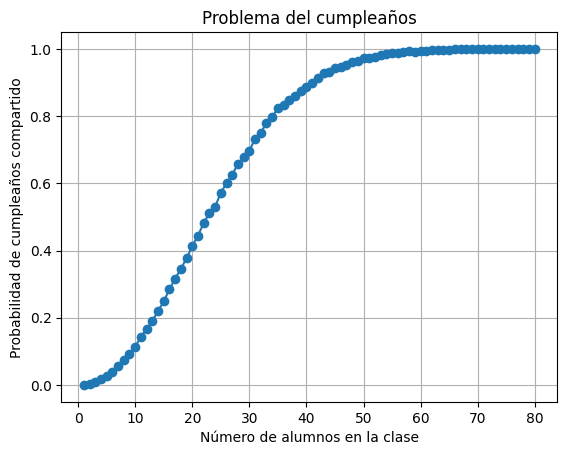

In [ ]:
def estima_probabilidad(clase, repeticiones=10000):
    dias = list(range(1, 366))
    resultados = [
        len(set(np.random.choice(dias, clase, replace=True))) < clase
        for _ in range(repeticiones)
    ]
    return np.mean(resultados)

clases = list(range(1, 81))
prob = [estima_probabilidad(n) for n in clases]

df = pd.DataFrame({"n": clases, "probabilidad": prob})
plt.plot(df["n"], df["probabilidad"], marker='o')
plt.xlabel("Número de alumnos en la clase")
plt.ylabel("Probabilidad de cumpleaños compartido")
plt.title("Problema del cumpleaños")
plt.grid(True)
plt.show()


Ya podemos impresionar a nuestros amigos de distintos grupos diciéndoles que, si están en un salón de 60 personas, “les pueden apostar” que hay dos personas en ese salón que cumplen años el mismo día. No es definitiva, pero las chances están muy a nuestro favor.

# **Desafio**

Ejercicio integrador

Explora e intenta implementar el ejercicio que integra todo lo que hemos aprendido hasta aqui, llamado el [problema de Monty Hall](https://www.youtube.com/watch?v=uz58hg0EJAY).

Monty Hall era un presentador de TV que hizo famoso un concurso en su show el cual vamos a replicar a continuación. Tenemos tres puertas frente a nosotros:

![](https://bookdown.org/dparedesi/data-science-con-r/img/monty-hall-cerradas.png)

Detrás de una de estas puertas hay un auto cero kilómetros, mientras que en las otras dos hay una cabra. Nosotros, como participantes del concurso, tenemos que elegir juntos qué puerta abrir. Lo que haya detrás será nuestro.

Supongamos que hemos elegido la puerta número 2. Una vez anuncias nuestra elección, Monty Hall nos dice que él nos va a ayudar y abrirá una puerta por nosotros ahora mismo. Él abre una de las otras puertas y resulta que hay una cabra en la puerta 3 que abrió.

![](https://bookdown.org/dparedesi/data-science-con-r/img/monty-hall-abierta.png)

Monty Hall nos pregunta:

> Les voy a dar una oportunidad de cambiar de puerta y esa será su elección final, ¿Cambiarían de puerta o se quedan con la puerta elegida al inicio?

Ver:

https://www.youtube.com/watch?v=uz58hg0EJAY

https://bookdown.org/dparedesi/data-science-con-r/probabilidades-discretas.html#ejercicio-integrador